In [28]:
import pandas as pd
#grid_df is the human mobility dataset; traj_df is the Massive step check-ins
grid_df = pd.read_csv("~/Downloads/humob_datasets/10836269/cell_POIcat.csv.gz")
poi_map = pd.read_csv("~/Downloads/humob_datasets/10836269/POI_datacategories.csv", header=None)
traj_df = pd.read_csv("~/Downloads/japan_checkins.csv")

In [29]:
# Human Mob 2023 - add category mapping
grid_df['POI_name'] = (grid_df['POIcategory'] - 1).map(poi_map.iloc[:,0])
# check mapping is correct
# grid_df[grid_df["POIcategory"] == 85]

In [33]:
# covert grid cells into LDA
grid_docs = []

for (x,y), g in grid_df.groupby(['x','y']):
    
    tokens = []
    
    for _, row in g.iterrows():
        tokens += [row['POI_name']] * int(row['POI_count'])
    
    grid_docs.append(tokens)
# chek output
# grid_docs[0]

In [40]:
from gensim import corpora

dictionary = corpora.Dictionary(grid_docs)

corpus = [dictionary.doc2bow(doc) for doc in grid_docs]

In [44]:
# Train LDA functional zone model
import gensim

lda = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,   # 10 target zones
    passes=20,
    random_state=42
)

In [45]:
for i in range(10):
    print(lda.print_topic(i))

0.494*"Elderly Care Home" + 0.153*"Sports Recreation" + 0.089*"Swimming Pool" + 0.070*"Park" + 0.058*"Hotel" + 0.032*"Entertainment" + 0.032*"Building Material" + 0.024*"Café" + 0.018*"Western restaurant" + 0.013*"Hot Spring"
0.176*"Japanese restaurant" + 0.131*"Bar" + 0.079*"Transit Station" + 0.066*"Wine Bar" + 0.054*"Hair Salon" + 0.050*"Café" + 0.046*"Western restaurant" + 0.027*"BBQ restaurant" + 0.027*"Ramen restaurant" + 0.022*"Chinese restaurant"
0.337*"Driving School" + 0.185*"Port" + 0.144*"Retail Store" + 0.066*"Laundry " + 0.064*"Building Material" + 0.037*"Post Office" + 0.021*"Heavy Industry" + 0.021*"Bank" + 0.015*"Cemetary" + 0.014*"Convenience Store"
0.809*"Church" + 0.113*"Gardening" + 0.026*"Cemetary" + 0.026*"Park" + 0.014*"Grocery Store" + 0.006*"Vet" + 0.006*"Café" + 0.000*"Building Material" + 0.000*"Disco" + 0.000*"Research Facility"
0.609*"Heavy Industry" + 0.092*"Building Material" + 0.083*"Home Appliances" + 0.055*"Retail Store" + 0.055*"Port" + 0.042*"Accoun

In [46]:
grid_topics = []

for doc in corpus:
    grid_topics.append(lda.get_document_topics(doc))

In [48]:
import numpy as np

num_topics = lda.num_topics

grid_vectors = []

for doc in corpus:
    
    vec = np.zeros(num_topics)
    
    for topic, prob in lda.get_document_topics(doc):
        vec[topic] = prob
    
    grid_vectors.append(vec)

In [50]:
bow = dictionary.doc2bow(['subway'])

lda.get_document_topics(bow)

[(0, 0.1),
 (1, 0.1),
 (2, 0.1),
 (3, 0.1),
 (4, 0.1),
 (5, 0.1),
 (6, 0.1),
 (7, 0.1),
 (8, 0.1),
 (9, 0.1)]

In [52]:
poi_map

,0
0,Food
1,Shopping
2,Entertainment
3,Japanese restaurant
4,Western restaurant
...,...
80,Heavy Industry
81,NPO
82,Utility Copany
83,Port


In [51]:
print(poi_map.head(100)) 

                      0
0                  Food
1              Shopping
2         Entertainment
3   Japanese restaurant
4    Western restaurant
..                  ...
80       Heavy Industry
81                  NPO
82       Utility Copany
83                 Port
84    Research Facility

[85 rows x 1 columns]


In [32]:
grid_df[grid_df["POIcategory"] == 85]

,x,y,POIcategory,POI_count,POI_name
309,1,34,85,1,Research Facility
1335,2,44,85,1,Research Facility
3199,9,41,85,1,Research Facility
3486,10,17,85,1,Research Facility
3722,11,6,85,1,Research Facility
...,...,...,...,...,...
218690,197,189,85,1,Research Facility
219887,199,38,85,1,Research Facility
220068,199,66,85,1,Research Facility
220567,199,198,85,1,Research Facility


In [ ]:
traj_df[traj_df["venue_city"] == "Osaka"]

In [29]:
#Massive filter on Osaka for now. To replace with final filtering. 
traj_df = traj_df[traj_df["venue_city"] == "Osaka"]

In [30]:
print(traj_df.head(10))

     trail_id  user_id  venue_id   latitude   longitude  \
2   2013_1784       46      8592  34.666083  135.503343   
3   2013_1784       46    167040        NaN         NaN   
6   2013_1791       46      4082  34.690005  135.518155   
7   2013_1791       46       513  34.645717  135.514089   
15  2013_1801       46      1889  34.662622  135.505059   
16  2013_1801       46      9131  34.700378  135.498514   
17  2013_1802       46      2806  34.660532  135.504835   
18  2013_1802       46     47991  34.660971  135.505555   
19  2013_1802       46     99017  34.661107  135.505989   
20  2013_1802       46     64834  34.676730  135.501352   

                                    name         address  \
2                                 マクドナルド    中央区千日前2-8-23   
3                                    NaN             NaN   
6                OMMビル (大阪マーチャンダイズマートビル)    中央区大手前1-7-31   
7   大阪阿部野橋駅 (Ōsaka-Abenobashi Sta.)(F01)  阿倍野区阿倍野筋1-1-43   
15                            ソフマップ なんば店    浪速区日本橋

In [31]:
traj_df = traj_df.sort_values(['trail_id','timestamp'])

sequences = (
    traj_df.groupby('trail_id')['venue_category']
    .apply(list)
    .tolist()
)

for seq in sequences[:5]:
    print(seq)

In [36]:
from gensim.models import Word2Vec

model = Word2Vec(
    sequences,
    vector_size=64,
    window=5,
    min_count=2,
    workers=4
)

poi_embedding = model.wv

In [38]:
poi_embedding['Metro Station']

array([-0.23225847, -0.46879455, -0.07749458,  0.15894628,  0.7606422 ,
       -0.24750379,  0.25543767,  0.58176994, -0.59422344, -0.43914378,
        0.46565178, -0.70831215,  0.5038833 ,  0.18359236,  0.545733  ,
       -0.02203611,  0.40581608,  0.02135887, -0.08739129,  0.6248899 ,
       -0.30418283,  0.22456838,  0.13516188, -0.15620083, -0.32636204,
        0.15635225, -0.27624425, -0.06723626, -0.05362468,  0.05834661,
        0.3810827 , -0.44761288, -0.6781544 , -0.47900906, -0.48876885,
        1.0291734 , -0.30246577,  0.2151584 ,  0.2099402 ,  0.42082757,
        0.18837409, -0.7456551 ,  0.04131253,  0.76471627, -0.2011751 ,
       -0.10655626, -0.11088157, -0.6241884 , -0.21850623, -0.07722357,
       -0.30607274,  0.17245881,  0.9920021 ,  0.5753949 ,  0.19226259,
       -0.27599952, -0.02708   , -0.5627923 ,  0.46063104, -0.34566912,
        0.5148028 , -0.14679281, -0.78611743,  0.15314443], dtype=float32)

In [39]:
grid_df = pd.read_csv("~/Downloads/humob_datasets/10836269/cell_POIcat.csv.gz")

pivot = grid_df.pivot_table(
    index=['x','y'],
    columns='POIcategory',
    values='POI_count',
    fill_value=0
)

In [40]:
import numpy as np

embedding_size = model.vector_size

grid_embeddings = []

for idx, row in pivot.iterrows():
    
    vec = np.zeros(embedding_size)
    total = 0
    
    for cat, count in row.items():
        
        if cat in poi_embedding:
            vec += poi_embedding[cat] * count
            total += count
            
    if total > 0:
        vec /= total
        
    grid_embeddings.append(vec)

grid_embeddings = np.array(grid_embeddings)

In [41]:
grid_embeddings.shape

(20146, 64)

In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=0)

zones = kmeans.fit_predict(grid_embeddings)

pivot['zone'] = zones

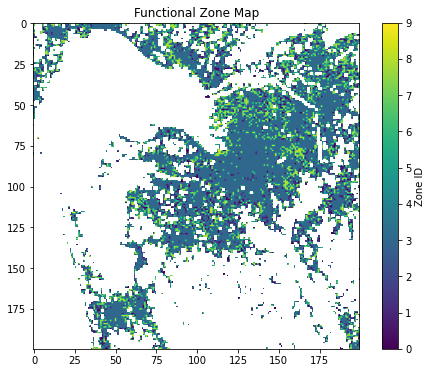

In [43]:
import matplotlib.pyplot as plt

zone_map = pivot.reset_index().pivot(
    index='y',
    columns='x',
    values='zone'
)

plt.figure(figsize=(8,6))
plt.imshow(zone_map)
plt.colorbar(label="Zone ID")
plt.title("Functional Zone Map")
plt.show()

In [9]:
print(len(df["venue_category"].unique()))
print(len(df["venue_category_id"].unique()))
print(len(df["venue_category_id_code"].unique()))

696
696
696


In [ ]:
poi_map = poi_map.drop_duplicates(subset=['POIcategory'])

In [44]:
pivot = grid_df.pivot_table(
    index=['x','y'],
    columns='POIcategory',
    values='POI_count',
    fill_value=0
)

In [45]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

X_tfidf = tfidf.fit_transform(pivot.values)

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)

X_reduced = pca.fit_transform(X_tfidf.toarray())

In [47]:
kmeans = KMeans(n_clusters=10)

zones = kmeans.fit_predict(X_reduced)

pivot['zone'] = zones

In [48]:
cluster_profile = pivot.groupby('zone').mean()

print(cluster_profile.T.sort_values(0,ascending=False).head(10))

zone                0         1         2         3         4         5  \
POIcategory                                                               
80           1.271860  0.044436  0.062451  0.111080  0.087756  0.054505   
81           0.413355  4.674139  2.018972  2.870779  3.331252  1.561735   
60           0.367250  0.676942  0.873518  1.520514  1.851197  0.506118   
74           0.327504  0.357886  0.516206  1.263466  1.237600  0.246941   
79           0.251192  0.804644  1.120158  1.849288  2.252515  0.688543   
73           0.162162  0.185749  0.300395  0.762769  0.579951  0.130145   
48           0.151033  0.337870  0.670356  2.759140  3.174124  0.319244   
76           0.136725  0.455564  0.642688  1.973207  1.961845  0.359288   
69           0.111288  0.317454  0.696443  4.118616  2.574402  0.212458   
54           0.106518  0.212970  0.377075  0.963997  1.171696  0.157953   

zone                6         7         8         9  
POIcategory                                  

In [ ]:
from scipy.spatial.distance import cosine

# Assume methodA_profile and methodB_profile are DataFrames:
# rows = clusters, columns = POI categories

similarity_matrix = 1 - np.array([
    [cosine(methodA_profile.iloc[i], methodB_profile.iloc[j])
     for j in range(methodB_profile.shape[0])]
    for i in range(methodA_profile.shape[0])
])

In [ ]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(methodA_zones.flatten(), methodB_zones.flatten())
print("Adjusted Rand Index:", ari)

In [ ]:
for zoneA in methodA_profile.index:
    for zoneB in methodB_profile.index:
        overlap = np.minimum(methodA_profile.loc[zoneA], methodB_profile.loc[zoneB]).sum()

In [54]:
print(traj_df["venue_category"].unique())

['University' 'College Theater' 'Fast Food Restaurant' 'Metro Station'
 'Train Station' 'Platform' 'Building' 'Temple' 'Bridge' 'Hobby Shop'
 'Bookstore' 'Arts & Crafts Store' 'Electronics Store' 'Multiplex'
 'Art Gallery' 'Japanese Restaurant' 'Theme Park' 'Shopping Mall'
 'Ramen Restaurant' 'Baseball Stadium' 'Soccer Field' 'Stadium' 'Island'
 'Seafood Restaurant' 'Diner' 'Bus Station' 'Hospital' 'School'
 'Deli / Bodega' 'General Entertainment' 'Office' 'Event Space' 'Plaza'
 'Concert Hall' 'Restaurant' 'Food' 'Hotel' 'Convention Center'
 'Music Venue' 'Italian Restaurant' 'Sake Bar' 'Monument / Landmark'
 'Government Building' 'Chinese Restaurant' 'City Hall' 'Trade School'
 'Park' 'Candy Store' 'Conference Room' 'Department Store' 'Coffee Shop'
 'Miscellaneous Shop' 'Bed & Breakfast' 'Grocery Store' 'Shop & Service'
 'Road' 'Record Shop' 'Café' 'Castle' 'Karaoke Bar' 'Convenience Store'
 'Post Office' 'Home (private)' 'Furniture / Home Store'
 'Residential Building (Apartment / Co

In [28]:
##print(df["venue_category"].unique()) 
print(sorted(df["venue_city"].unique()) )
print("Min time:", df["timestamp"].min())
print("Max time:", df["timestamp"].max())

['Agano', 'Akashi', 'Aki', 'Ako', 'Akune', 'Amagasaki', 'Amagi', 'Amami', 'Ami', 'Anan', 'Anjō', 'Annaka', 'Aomori', 'Asaka', 'Ashibetsu', 'Ashikaga', 'Ashiya', 'Aso', 'Ayabe', 'Azumino', 'Chiba', 'Chichibu', 'Chikusei', 'Chiryū', 'Chita', 'Chitose', 'Daigo', 'Daisen', 'Daitōchō', 'Dazaifu', 'Ena', 'Fuji', 'Fujieda', 'Fujikawaguchiko', 'Fujinomiya', 'Fujioka', 'Fujisawa', 'Fukagawa', 'Fukuchiyama', 'Fukumitsu', 'Fukushima', 'Funabashi', 'Fussa', 'Futtsu', 'Gamagōri', 'Gero', 'Ginowan', 'Gose', 'Gosen', 'Goshogawara', 'Gujō', 'Gushikawa', 'Gyōda', 'Gōdo', 'Hachimantai', 'Hachiōji', 'Hagi', 'Hakodate', 'Hakui', 'Hamada', 'Hamakita', 'Handa', 'Hannan', 'Hashima', 'Hashimoto', 'Hasuda', 'Hekinan', 'Hida', 'Hidaka', 'Higashimurayama', 'Himeji', 'Hino', 'Hioki', 'Hirado', 'Hirakawa', 'Hiratsuka', 'Hirosaki', 'Hita', 'Honjō', 'Hōfu', 'Hōjō', 'Ibara', 'Ibusuki', 'Ichinomiya', 'Ichinoseki', 'Iida', 'Iizuka', 'Ikoma', 'Imizu', 'Ina', 'Inabe', 'Inashiki', 'Inawashiro', 'Ino', 'Isahaya', 'Isawa', 

In [4]:
df2 = pd.read_csv("~/Downloads/humob_datasets/10836269/yjmob100k-dataset2.csv.gz")

In [6]:
df2.shape

(221159, 4)

In [5]:
print(df2.head(100))

    x   y  POIcategory  POI_count
0   1   1           48          4
1   1   1           58          1
2   1   1           59          1
3   1   1           69          2
4   1   1           73          1
.. ..  ..          ...        ...
95  1  10           48          4
96  1  10           51          2
97  1  10           52          1
98  1  10           53          1
99  1  10           56          1

[100 rows x 4 columns]


In [7]:
df4 = pd.read_csv("~/Downloads/humob_datasets/10836269/POI_datacategories.csv")
print(df4.head(100))

                          Food
0                     Shopping
1                Entertainment
2          Japanese restaurant
3           Western restaurant
4   Eat all you can restaurant
..                         ...
79              Heavy Industry
80                         NPO
81              Utility Copany
82                        Port
83           Research Facility

[84 rows x 1 columns]


In [6]:
pivot = df2.pivot_table(
    index=['x','y'],
    columns='POIcategory',
    values='POI_count',
    fill_value=0
)

In [11]:
print(pivot)

POIcategory  1   2   3   4   5   6   7   8   9   10  ...  76  77  78  79  80  \
x   y                                                ...                       
1   1         0   0   0   0   0   0   0   0   0   0  ...   0   0   0   2   0   
    2         0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   1   
    3         0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
    4         0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
    5         0   0   0   0   0   0   0   0   0   0  ...   1   0   0   0   0   
...          ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ..  ..  ..  ..  ..   
200 196       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   
    197       0   0   0   1   0   0   0   0   0   0  ...   1   0   0   0   0   
    198       0   0   0   1   0   0   1   0   0   0  ...   0   0   0   1   0   
    199       0   0   0   1   2   0   0   0   0   0  ...   0   0   0   0   0   
    200       0   0   0   0   0   0   0 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

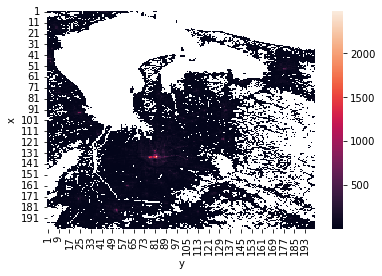

In [9]:
grid = df2.groupby(['x','y'])['POI_count'].sum().unstack()

sns.heatmap(grid)
plt.show()

In [12]:
df2.groupby('POIcategory')['POI_count'].sum().sort_values()

POIcategory
29        1
24        2
28        2
30        4
25       24
      ...  
79    20547
69    25716
48    25758
81    39226
59    42806
Name: POI_count, Length: 85, dtype: int64

In [13]:
import pandas as pd

def create_poi_lookup(poi_path):
    # Load data: x, y, poi_category (int), count
    df_poi = pd.read_csv(poi_path)
    
    # 1. Find the category with the highest count for each grid cell
    # Sort by count descending and keep the first entry for each x,y
    primary_df = df_poi.sort_values('POI_count', ascending=False).drop_duplicates(['x', 'y'])
    
    # 2. Shift IDs by 1 so that '0' is reserved for "No POI"
    # If your categories are 0-84, they become 1-85.
    primary_df['poi_id'] = primary_df['POIcategory'] + 1
    
    # 3. Create the lookup dictionary: {(x, y): poi_id}
    poi_lookup = primary_df.set_index(['x', 'y'])['poi_id'].to_dict()
    
    # Vocab size is the max category number + 1 (for the zero padding)
    vocab_size = int(df_poi['POIcategory'].max() + 2) 
    
    return poi_lookup, vocab_size

# Usage:
# poi_lookup, poi_vocab_size = create_poi_lookup('poi_data.csv')

In [ ]:
import pandas as pd
import numpy as np

def process_massive_steps_to_grid(file_path):
    # 1. Load Massive-STEPS
    df = pd.read_csv(file_path)
    
    # 2. Define the Grid Resolution (Approx 500m in degrees)
    # 0.0045 degrees is roughly 500 meters
    LAT_STEP = 0.0045
    LON_STEP = 0.0055 # Longitude varies by latitude, 0.0055 is a good avg for Japan
    
    # 3. Create Grid Indices
    # We use 'floor' to bin coordinates into the same cell
    df['grid_x'] = (df['longitude'] / LON_STEP).apply(np.floor).astype(int)
    df['grid_y'] = (df['latitude'] / LAT_STEP).apply(np.floor).astype(int)
    
    # Normalize indices so they start at 0 (Relative Grid)
    df['grid_x'] = df['grid_x'] - df['grid_x'].min()
    df['grid_y'] = df['grid_y'] - df['grid_y'].min()
    
    # 4. Aggregate: Count venue categories per cell
    # This creates a "Profile" for every grid cell
    grid_profile = df.groupby(['grid_x', 'grid_y', 'venue_category']).size().reset_index(name='count')
    
    # 5. Get Primary Function per cell
    # For each grid cell, find which category is most common
    primary_function = grid_profile.sort_values('count', ascending=False).drop_duplicates(['grid_x', 'grid_y'])
    
    return primary_function, df[['user_id', 'timestamp', 'grid_x', 'grid_y', 'venue_category']]

# Run the conversion
# grid_map, traj_data = process_massive_steps_to_grid('massive_steps.csv')

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

def generate_functional_zones(poi_counts_df, n_zones=10):
    # poi_counts_df columns: x, y, cat_1, cat_2 ... cat_85
    features = poi_counts_df.drop(columns=['x', 'y'])
    
    # Normalize the data (so density doesn't bias the cluster)
    features_norm = features.div(features.sum(axis=1) + 1e-9, axis=0)
    
    # Run K-Means
    kmeans = KMeans(n_clusters=n_zones, random_state=42)
    poi_counts_df['zone_id'] = kmeans.fit_predict(features_norm)
    
    # Create lookup: {(x, y): zone_id}
    zone_lookup = poi_counts_df.set_index(['x', 'y'])['zone_id'].to_dict()
    return zone_lookup

# zone_lookup = generate_functional_zones(your_poi_df)

In [ ]:
import pandas as pd
import numpy as np

def prepare_urban_pretraining_data(file_path):
    # 1. Load the Massive-STEPS data
    df = pd.read_csv(file_path)
    
    # 2. Select Key Urban Regions (matching Group 3's "High Density" logic)
    # These cities represent the most complex urban mobility patterns in Japan
    target_cities = [
        'Tokyo', 'Osaka', 'Nagoya', 'Kobe', 'Kyoto', 
        'Yokohama', 'Fukuoka', 'Kawasaki', 'Saitama'
    ]
    
    df_urban = df[df['venue_city'].isin(target_cities)].copy()
    
    # 3. 500m Grid Conversion Math
    # Latitude: 1 degree ~ 111km -> 0.0045 deg ~ 500m
    # Longitude: 1 degree ~ 90km (in Japan) -> 0.0055 deg ~ 500m
    LAT_STEP = 0.0045
    LON_STEP = 0.0055
    
    df_urban['grid_x'] = (df_urban['longitude'] / LON_STEP).apply(np.floor).astype(int)
    df_urban['grid_y'] = (df_urban['latitude'] / LAT_STEP).apply(np.floor).astype(int)
    
    # 4. Create a "Functional Map" of these cities
    # This helps your model understand what each cell "means"
    grid_meanings = df_urban.groupby(['grid_x', 'grid_y', 'venue_category']).size().reset_index(name='count')
    
    # 5. Filter for Trajectory Continuity
    # Keep users who have at least 5 check-ins (so BERT has a sequence to learn from)
    user_counts = df_urban['user_id'].value_counts()
    active_users = user_counts[user_counts >= 5].index
    df_final = df_urban[df_urban['user_id'].isin(active_users)]
    
    print(f"Original Data: {len(df)} rows")
    print(f"Urban Filtered: {len(df_final)} rows")
    print(f"Unique Urban Cells: {df_final.groupby(['grid_x', 'grid_y']).ngroups}")
    
    return df_final, grid_meanings

# Execute
# urban_trajectories, urban_poi_map = prepare_urban_pretraining_data('massive_steps.csv')